# Lab for Week 6: Exploratory Data Analysis (EDA) 

Today, we'll practice Exploratory Data Analysis (EDA) using a real-world dataset: NYC Airbnb listings.  
The goal is to understand the data, clean it, encode categorical variables, and uncover patterns through visualization.

**Objective:** You will perform a step-by-step EDA process, from loading the data to visualizing key relationships, while reinforcing concepts like label encoding, one-hot encoding, and binning.

Source: https://www.kaggle.com/datasets/dgomonov/new-york-city-airbnb-open-data

## Dataset

This dataset contains detailed listing information for Airbnb properties across New York City, including price, location, room type, host activity, and review data. 

### __Variables__

* id: Unique identifier for each listing
* name: Name/title of the listing
* host_id: Unique identifier for the host
* host_name: Name of the host
* neighbourhood_group: Borough of NYC (Manhattan, Brooklyn, Queens, Bronx, Staten Island)
* neighbourhood: Specific neighbourhood within the borough
* latitude: Latitude coordinate of the listing
* longitude: Longitude coordinate of the listing
* room_type: Type of room offered (Entire home/apt, Private room, Shared room)
* price: Price per night, in USD
* minimum_nights: Minimum number of nights required to book
* number_of_reviews: Total number of reviews the listing has received
* last_review: Date of the most recent review
* reviews_per_month: Average number of reviews per month
* calculated_host_listings_count: Number of listings the host has in total
* availability_365: Number of days in the year the listing is available for booking

## What is Exploratory Data Analysis (EDA)?

EDA is the first and most important step in any data science and machine learning process. Its the process of analyzing a dataset to understand it.

The goals of EDA are to:

- Discover patterns in the data
  
- Spot anomalies or unusual values
  
- Test assumptions or hypotheses
  
- Uncover hidden insights
  
- To prevent errors and biases from being carried into later analysis.

## 0. Libraries

In [41]:
# Include necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

## 1. Acquire Data

In [42]:
# Load the dataset
df = pd.read_csv('dataset/AB_NYC_2019.csv')

# Display the first 5 rows to get a quick look at the data
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [43]:
df.shape

(48895, 16)

In [44]:
df.columns

Index(['id', 'name', 'host_id', 'host_name', 'neighbourhood_group',
       'neighbourhood', 'latitude', 'longitude', 'room_type', 'price',
       'minimum_nights', 'number_of_reviews', 'last_review',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365'],
      dtype='object')

In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

In [46]:
df.dtypes

id                                  int64
name                               object
host_id                             int64
host_name                          object
neighbourhood_group                object
neighbourhood                      object
latitude                          float64
longitude                         float64
room_type                          object
price                               int64
minimum_nights                      int64
number_of_reviews                   int64
last_review                        object
reviews_per_month                 float64
calculated_host_listings_count      int64
availability_365                    int64
dtype: object

In [47]:
df.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,1.373221,7.143982,112.781327
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,1.680442,32.952519,131.622289
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


## 2. Prepare Data

### Check for duplicate rows

Before diving into analysis, it's good practice to check for duplicate rows, they can skew statistics and visualizations if left in.

In [48]:
# Check for duplicate rows
df.duplicated(keep=False).sum()

np.int64(0)

In [49]:
# Show duplicated rows (if any)
df[df.duplicated(keep=False)]

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365


In [50]:
# Drop duplicate rows
df.drop_duplicates(inplace=True)
df.duplicated(keep=False).sum()

np.int64(0)

### Convert categorical columns to `category` dtype

By default, pandas loads text columns as generic `object` dtype. Converting known categorical columns to the `category` dtype is more memory-efficient and lets us use category-specific tools, like describing them separately from numeric columns.

In [51]:
# Convert to category dtype
df['neighbourhood_group'] = df['neighbourhood_group'].astype('category')
df['neighbourhood'] = df['neighbourhood'].astype('category')
df['room_type'] = df['room_type'].astype('category')

df.dtypes

id                                   int64
name                                object
host_id                              int64
host_name                           object
neighbourhood_group               category
neighbourhood                     category
latitude                           float64
longitude                          float64
room_type                         category
price                                int64
minimum_nights                       int64
number_of_reviews                    int64
last_review                         object
reviews_per_month                  float64
calculated_host_listings_count       int64
availability_365                     int64
dtype: object

In [52]:
# Describe only categorical columns
df.describe(include=['category'])

,neighbourhood_group,neighbourhood,room_type
count,48895,48895,48895
unique,5,221,3
top,Manhattan,Williamsburg,Entire home/apt
freq,21661,3920,25409


In [53]:
# Describe remaining object-type (text) columns
df.describe(include=[object])

,name,host_name,last_review
count,48879,48874,38843
unique,47905,11452,1764
top,Hillside Hotel,Michael,2019-06-23
freq,18,417,1413


### Dropping irrelevant columns

Some columns don't add value for our EDA, `id`, `name`, `host_name`, and `last_review` are identifiers or free text that won't help us understand patterns in price, room type, or location. We'll drop them to keep the dataset focused.

In [54]:
# Drop columns not needed for our analysis
df.drop(['id', 'name', 'host_name', 'last_review'], axis=1, inplace=True)
df.head()

,host_id,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
0,2787,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,0.21,6,365
1,2845,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,0.38,2,355
2,4632,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,1,365
3,4869,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,4.64,1,194
4,7192,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,0.10,1,0


### Handling missing values

Let's check for missing values, and this time also apply a systematic threshold, flagging any column where more than 90% of the data is missing, which would be a strong candidate to drop entirely.

In [55]:
df.isnull().sum()

host_id                               0
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64

In [56]:
df.shape

(48895, 12)

In [57]:
# Find columns with more than 90% missing data
cols_to_delete = df.columns[df.isnull().sum() / len(df) > 0.90]
cols_to_delete

Index([], dtype='object')

### Filling missing values in `reviews_per_month`

The missing values here aren't random, they correspond to listings that have never received a review, so there's no rate to calculate. Filling with the mean would misrepresent these as "average" listings, when really they should be treated as zero.

In [58]:
# Fill missing reviews_per_month with 0 (no reviews = 0 rate)
df['reviews_per_month'] = df['reviews_per_month'].fillna(0)
df.isnull().sum()

host_id                           0
neighbourhood_group               0
neighbourhood                     0
latitude                          0
longitude                         0
room_type                         0
price                             0
minimum_nights                    0
number_of_reviews                 0
reviews_per_month                 0
calculated_host_listings_count    0
availability_365                  0
dtype: int64

### Checking categorical columns before encoding

Before encoding, let's look at the unique values and their counts for our key categorical columns.

In [59]:
df['room_type'].value_counts()

room_type
Entire home/apt    25409
Private room       22326
Shared room         1160
Name: count, dtype: int64

In [60]:
df['neighbourhood_group'].value_counts()

neighbourhood_group
Manhattan        21661
Brooklyn         20104
Queens            5666
Bronx             1091
Staten Island      373
Name: count, dtype: int64

In [61]:
df['neighbourhood'].value_counts()

neighbourhood
Williamsburg          3920
Bedford-Stuyvesant    3714
Harlem                2658
Bushwick              2465
Upper West Side       1971
                      ... 
Richmondtown             1
Willowbrook              1
Fort Wadsworth           1
New Dorp                 1
Woodrow                  1
Name: count, Length: 221, dtype: int64

In [62]:
df['neighbourhood'].nunique()

221

`neighbourhood` has far too many unique values to one-hot encode without creating an unmanageable number of columns.

### Groupby aggregation

Before encoding, let's compare categories numerically using `groupby`, a technique that complements value counts by showing how key metrics differ across groups.

In [63]:
# Average price and reviews by room type
df.groupby('room_type').mean(numeric_only=True)

/var/folders/4c/qvr7f7s55bxgydyf0y98d18w0000gn/T/ipykernel_71824/1670630349.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('room_type').mean(numeric_only=True)


,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
room_type,,,,,,,,,
Entire home/apt,6.175593e+07,40.728649,-73.960696,211.794246,8.506907,22.842418,1.045509,10.698335,111.920304
Private room,7.247514e+07,40.729208,-73.942924,89.780973,5.377900,24.112962,1.143493,3.227717,111.203933
Shared room,1.026241e+08,40.730514,-73.943343,70.127586,6.475000,16.600000,1.073345,4.662931,162.000862


In [64]:
# Average price and reviews by borough
df.groupby('neighbourhood_group').mean(numeric_only=True)

/var/folders/4c/qvr7f7s55bxgydyf0y98d18w0000gn/T/ipykernel_71824/2533446200.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('neighbourhood_group').mean(numeric_only=True)


,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
neighbourhood_group,,,,,,,,,
Bronx,1.056099e+08,40.848305,-73.884552,87.496792,4.560953,26.004583,1.475655,2.233731,165.758937
Brooklyn,5.671526e+07,40.685036,-73.951190,124.383207,6.056556,24.202845,1.049790,2.284371,100.232292
Manhattan,6.783062e+07,40.765062,-73.974607,196.875814,8.579151,20.985596,0.976782,12.791330,111.979410
Queens,9.615680e+07,40.731531,-73.872775,99.517649,5.181433,27.700318,1.567076,4.060184,144.451818
Staten Island,9.853360e+07,40.610225,-74.105805,114.812332,4.831099,30.941019,1.576381,2.319035,199.678284


In [65]:
# Standard deviation of price by room type (spread within each group)
df.groupby('room_type').std(numeric_only=True)

/var/folders/4c/qvr7f7s55bxgydyf0y98d18w0000gn/T/ipykernel_71824/3686470499.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('room_type').std(numeric_only=True)


,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
room_type,,,,,,,,,
Entire home/apt,7.699118e+07,0.050619,0.042551,284.041611,22.947336,42.408837,1.486103,44.381193,129.802937
Private room,7.905584e+07,0.058214,0.048025,160.205262,16.292091,47.286746,1.717162,10.218641,132.092065
Shared room,8.905235e+07,0.063149,0.049384,101.725252,31.458825,34.185006,1.522697,6.218151,151.347109


### Encoding categorical variables

Machine learning and many analysis techniques require numeric input, so we need to convert categorical (text) variables into numbers. There are two common approaches:

**Label Encoding**: assigns each unique category an integer (e.g., "Private room" → 0, "Entire home/apt" → 1, "Shared room" → 2). It's simple and works well for variables with few categories, especially where a natural order isn't implied.

**One-Hot Encoding**: creates a separate binary (0/1) column for each category, indicating presence/absence. It avoids implying any ordinal relationship between categories, which matters when categories are purely nominal (no inherent rank). It's best suited for low-cardinality variables, since each category becomes its own column.

We'll use label encoding for `room_type` (only 3 categories) and one-hot encoding for `neighbourhood_group` (5 categories).

In [66]:
# Label Encoding to turn room_type into numerical values
label_encoder = LabelEncoder()
df['room_type_encoded'] = label_encoder.fit_transform(df['room_type'])

df[['room_type', 'room_type_encoded']].value_counts()

room_type        room_type_encoded
Entire home/apt  0                    25409
Private room     1                    22326
Shared room      2                     1160
Name: count, dtype: int64

In [67]:
df.dtypes

host_id                              int64
neighbourhood_group               category
neighbourhood                     category
latitude                           float64
longitude                          float64
room_type                         category
price                                int64
minimum_nights                       int64
number_of_reviews                    int64
reviews_per_month                  float64
calculated_host_listings_count       int64
availability_365                     int64
room_type_encoded                    int64
dtype: object

In [68]:
# One-hot encode neighbourhood_group
df = pd.get_dummies(df, columns=['neighbourhood_group'], drop_first=True)

df.head()

,host_id,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,room_type_encoded,neighbourhood_group_Brooklyn,neighbourhood_group_Manhattan,neighbourhood_group_Queens,neighbourhood_group_Staten Island
0,2787,Kensington,40.64749,-73.97237,Private room,149,1,9,0.21,6,365,1,True,False,False,False
1,2845,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,0.38,2,355,0,False,True,False,False
2,4632,Harlem,40.80902,-73.94190,Private room,150,3,0,0.00,1,365,1,False,True,False,False
3,4869,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,4.64,1,194,0,True,False,False,False
4,7192,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,0.10,1,0,0,False,True,False,False


In [69]:
df.dtypes

host_id                                 int64
neighbourhood                        category
latitude                              float64
longitude                             float64
room_type                            category
price                                   int64
minimum_nights                          int64
number_of_reviews                       int64
reviews_per_month                     float64
calculated_host_listings_count          int64
availability_365                        int64
room_type_encoded                       int64
neighbourhood_group_Brooklyn             bool
neighbourhood_group_Manhattan            bool
neighbourhood_group_Queens               bool
neighbourhood_group_Staten Island        bool
dtype: object

### Why `drop_first=True`?

When one-hot encoding a categorical variable, we can actually represent all categories using one fewer column than the number of categories. If we know a listing is *not* Brooklyn, *not* Manhattan, *not* Queens, and *not* Staten Island, it must belong to the one remaining category (Bronx, in this case), so that column is redundant.

### Binning: `price` into categories

Binning converts a continuous numerical variable into discrete categories (bins), making patterns easier to interpret — especially when the raw values are skewed or span a huge range.

In [70]:
# Bin price into categories
bins = [0, 50, 100, 200, 10000]
labels = ['Budget', 'Mid-range', 'High', 'Luxury']

df['price_category'] = pd.cut(df['price'], bins=bins, labels=labels)

df['price_category'].value_counts()

price_category
Mid-range    17367
High         16583
Luxury        8384
Budget        6550
Name: count, dtype: int64

## 3. Analyze the Data

### 3.1 Univariate Analysis

Univariate analysis looks at one variable at a time to understand its distribution — how values are spread, whether they're skewed, and where outliers lie. Common visualizations include histograms, boxplots, and bar/count charts.

We'll start with `price`.

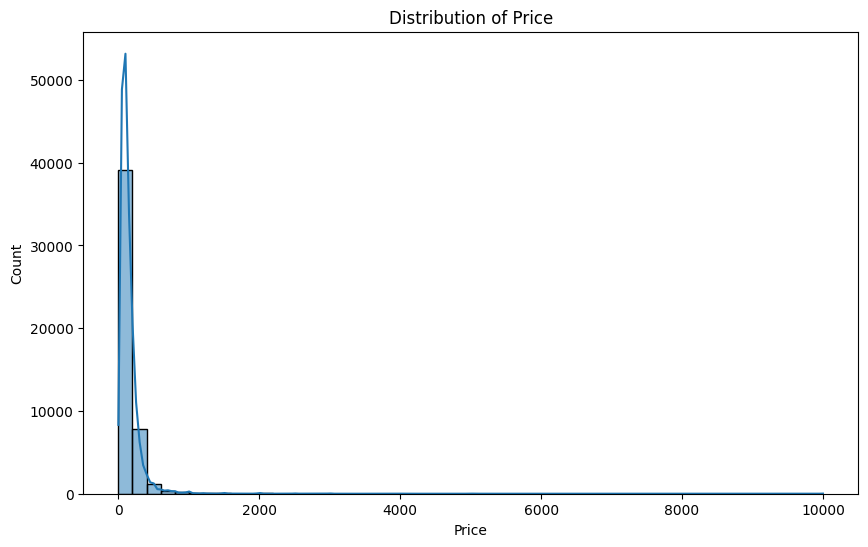

In [71]:
# Distribution of price
plt.figure(figsize=(10, 6))
sns.histplot(df['price'], bins=50, kde=True)
plt.title('Distribution of Price')
plt.xlabel('Price')
plt.ylabel('Count')
plt.show()

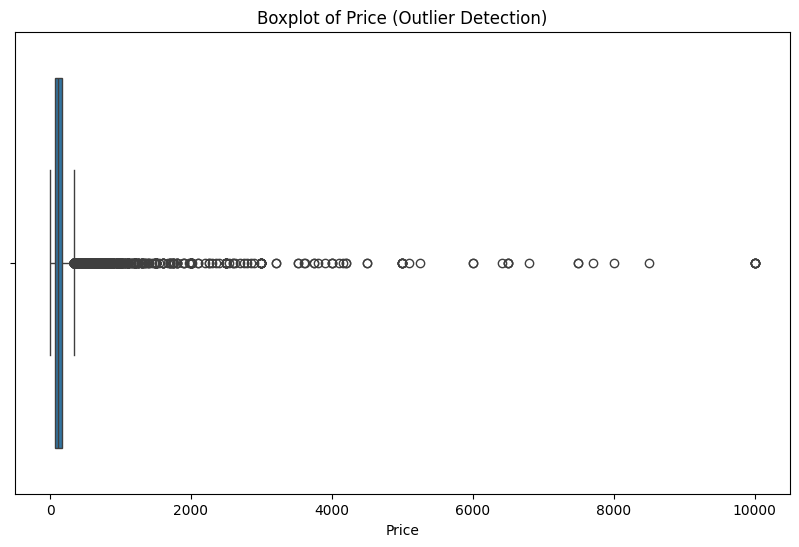

In [72]:
# Boxplot to spot outliers in price
plt.figure(figsize=(10, 6))
sns.boxplot(x=df['price'])
plt.title('Boxplot of Price (Outlier Detection)')
plt.xlabel('Price')
plt.show()

### Cleaning the `price` column

The boxplot confirmed extreme outliers (up to $10,000/night). We'll use the **IQR (Interquartile Range) method** to identify a reasonable upper bound, with some leniency built in, since genuinely expensive listings shouldn't be treated the same as data errors.

In [73]:
# Calculate IQR for price
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1

upper_bound = Q3 + 1.5 * IQR
lenient_upper_bound = upper_bound * 10
print(f"Strict upper bound: {upper_bound}")
print(f"Lenient upper bound: {lenient_upper_bound}")

Strict upper bound: 334.0
Lenient upper bound: 3340.0


In [74]:
# Filter out extreme outliers, allowing leniency for genuinely high-end listings
df = df[df['price'] <= lenient_upper_bound]
df.shape

(48852, 17)

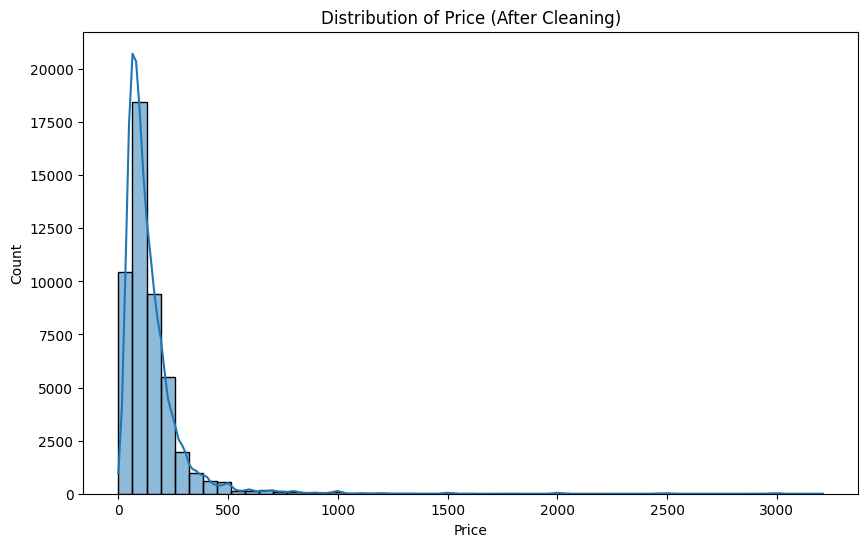

In [75]:
# Re-plot to confirm the effect of cleaning
plt.figure(figsize=(10, 6))
sns.histplot(df['price'], bins=50, kde=True)
plt.title('Distribution of Price (After Cleaning)')
plt.xlabel('Price')
plt.ylabel('Count')
plt.show()

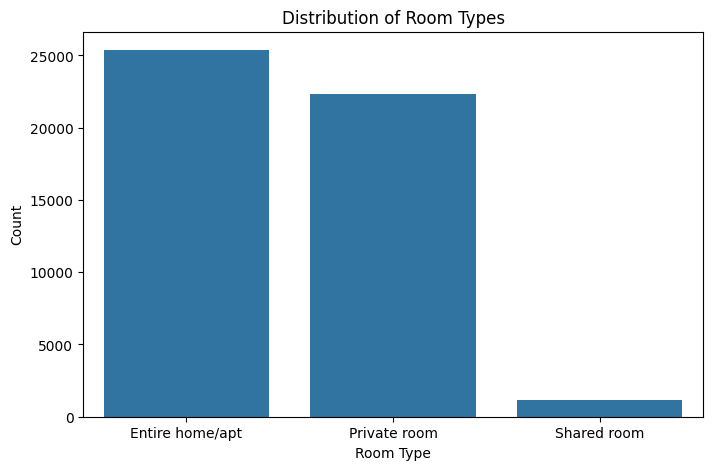

In [76]:
# Countplot: distribution of room types
plt.figure(figsize=(8, 5))
sns.countplot(x='room_type', data=df)
plt.title('Distribution of Room Types')
plt.xlabel('Room Type')
plt.ylabel('Count')
plt.show()

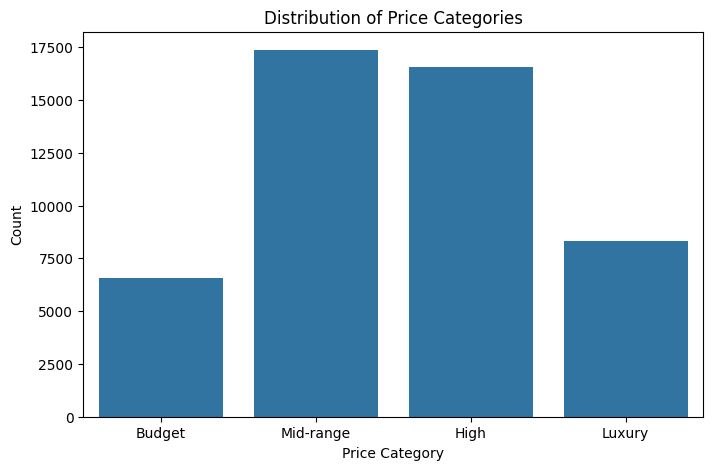

In [77]:
# Countplot: distribution of price categories
plt.figure(figsize=(8, 5))
sns.countplot(x='price_category', data=df, order=['Budget', 'Mid-range', 'High', 'Luxury'])
plt.title('Distribution of Price Categories')
plt.xlabel('Price Category')
plt.ylabel('Count')
plt.show()

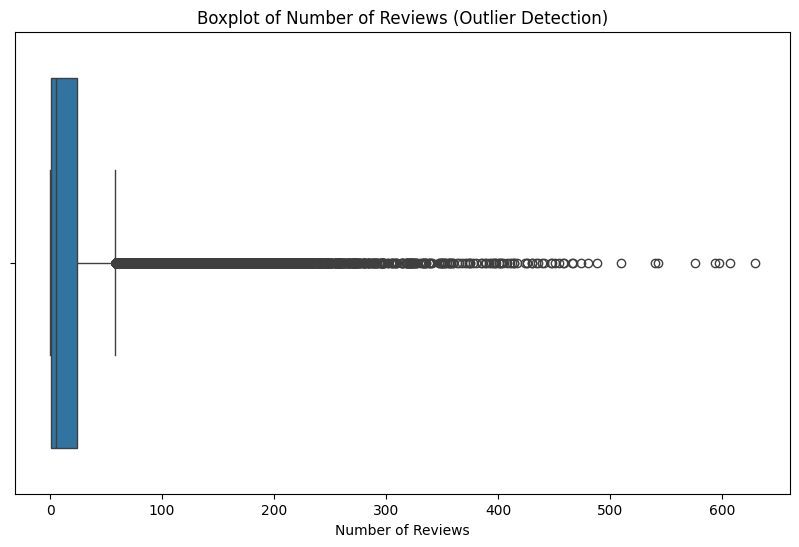

In [78]:
# Boxplot: number_of_reviews distribution
plt.figure(figsize=(10, 6))
sns.boxplot(x=df['number_of_reviews'])
plt.title('Boxplot of Number of Reviews (Outlier Detection)')
plt.xlabel('Number of Reviews')
plt.show()

### Multi-panel boxplot: spotting outliers across features at once

Rather than plotting one boxplot at a time, we can loop through several numeric features and lay them out in a grid, a fast way to scan for outliers across the whole dataset at once.

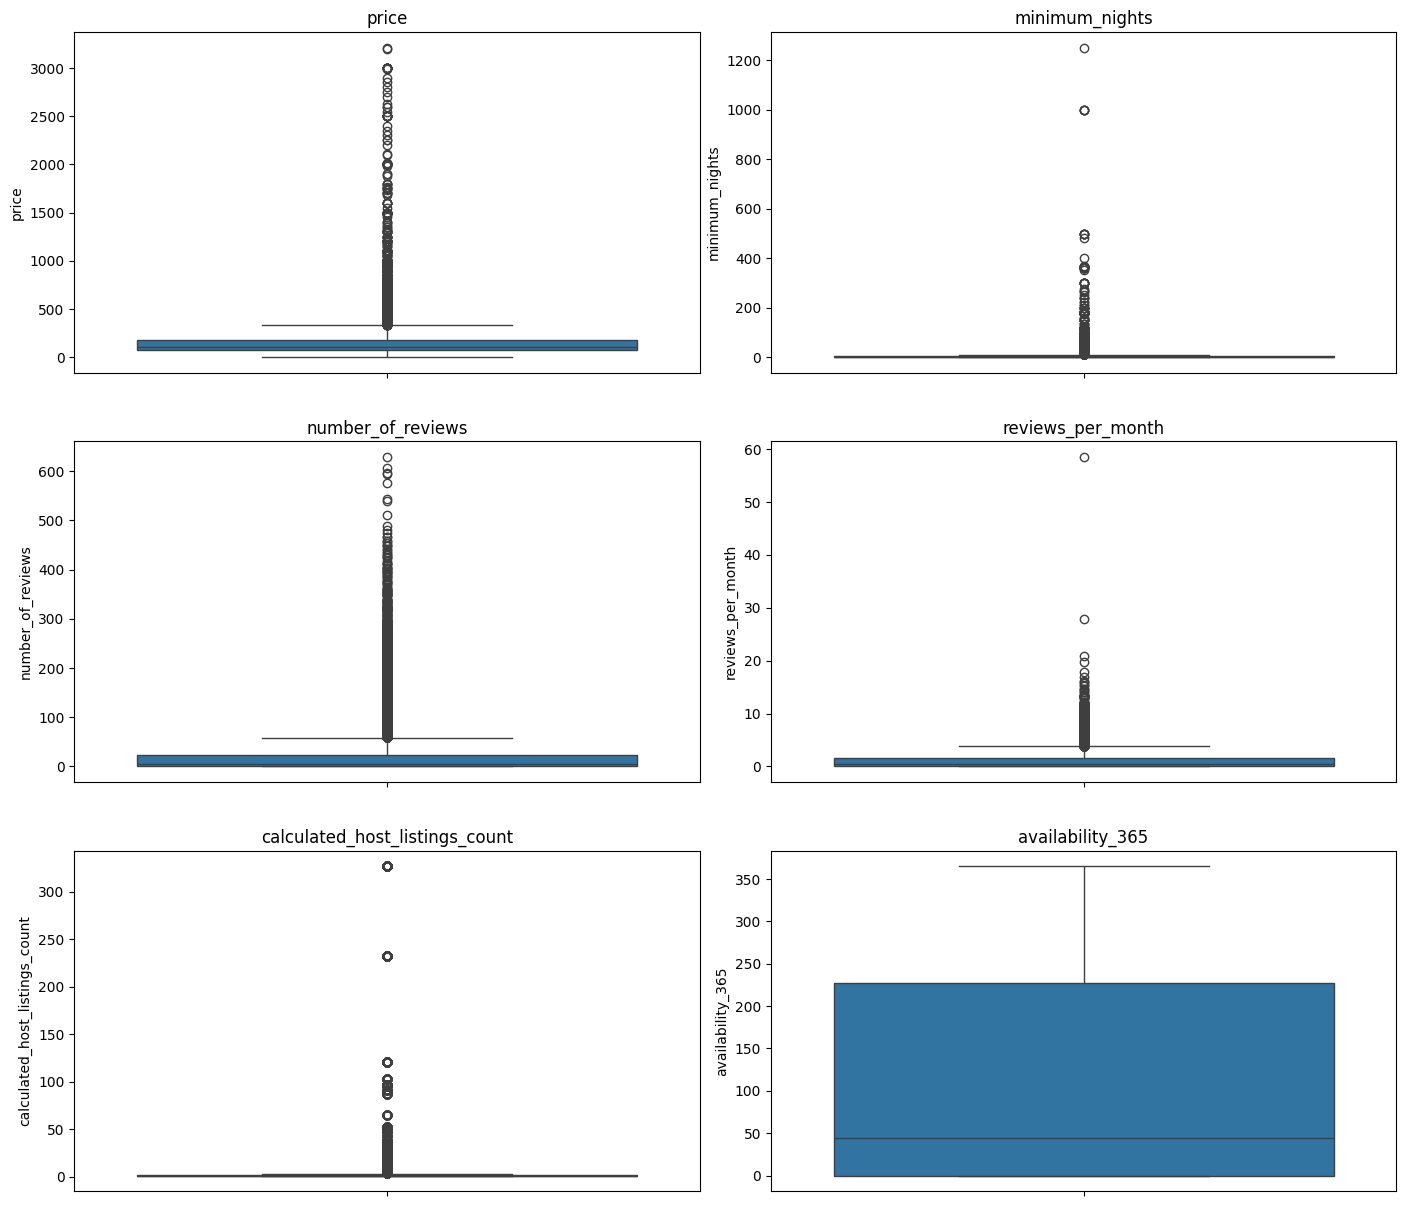

In [79]:
# Plot boxplots of all numeric features in a grid
numeric_features = ['price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month',
                     'calculated_host_listings_count', 'availability_365']

fig, axs = plt.subplots(ncols=2, nrows=3, figsize=(14, 12))
axs = axs.flatten()

for i, col in enumerate(numeric_features):
    sns.boxplot(y=df[col], ax=axs[i])
    axs[i].set_title(col)

plt.tight_layout(pad=0.5, w_pad=0.5, h_pad=3)
plt.show()

### Mini Exercise

Using the multi-panel boxplot above, pick **one feature** that shows heavy outliers (e.g., `minimum_nights` or `calculated_host_listings_count`) and:

1. Plot its histogram to see the shape of the distribution.
2. Calculate its IQR-based upper bound (like we did for `price`).
3. Decide, would you filter it the same way, more strictly, or leave it as-is? Justify your answer in 1–2 sentences.

In [80]:
# YOUR CODE HERE

### 3.2 Bivariate / Multivariate Analysis

Bivariate/multivariate analysis looks at relationships between two or more variables. Common visualizations include correlation matrices, scatterplots, pairplots, and boxplots grouped by category.

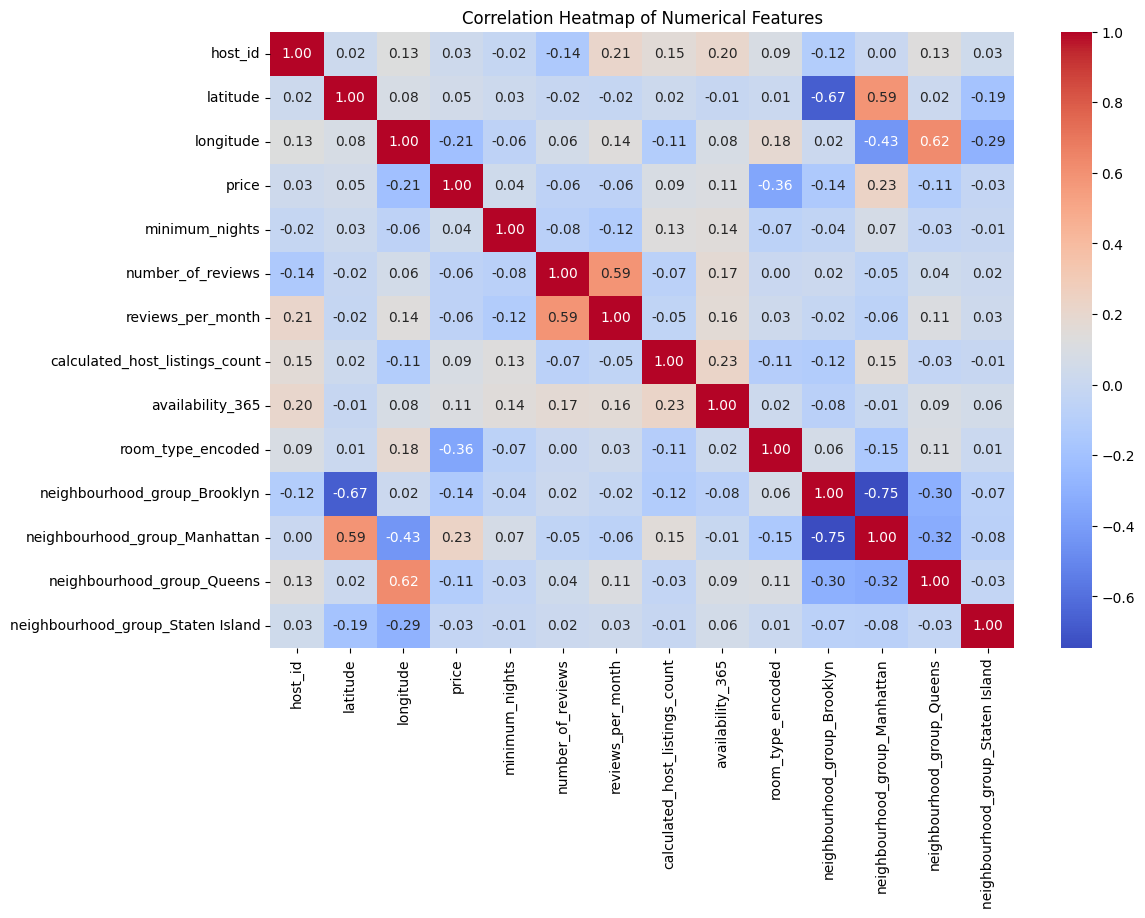

In [81]:
# Correlation heatmap of numerical columns
plt.figure(figsize=(12, 8))
num_col = df.select_dtypes(include=['int64', 'float64', 'bool'])
sns.heatmap(num_col.corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

- **`room_type_encoded` and `price` (-0.36)**: the strongest relationship in the matrix. Worth exploring further with a boxplot.
- **`longitude` and `price` (-0.21)**: a mild relationship, hinting that location (moving east/west across NYC) has some association with price.



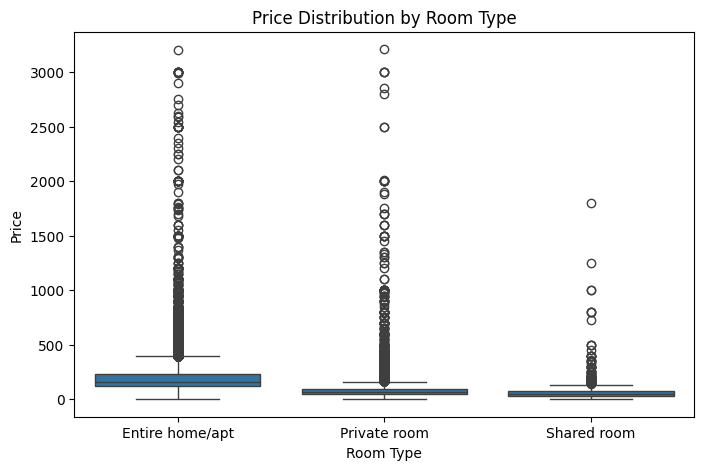

In [83]:
# Visualize room_type and price
plt.figure(figsize=(8, 5))
sns.boxplot(x='room_type', y='price', data=df)
plt.title('Price Distribution by Room Type')
plt.xlabel('Room Type')
plt.ylabel('Price')
plt.show()

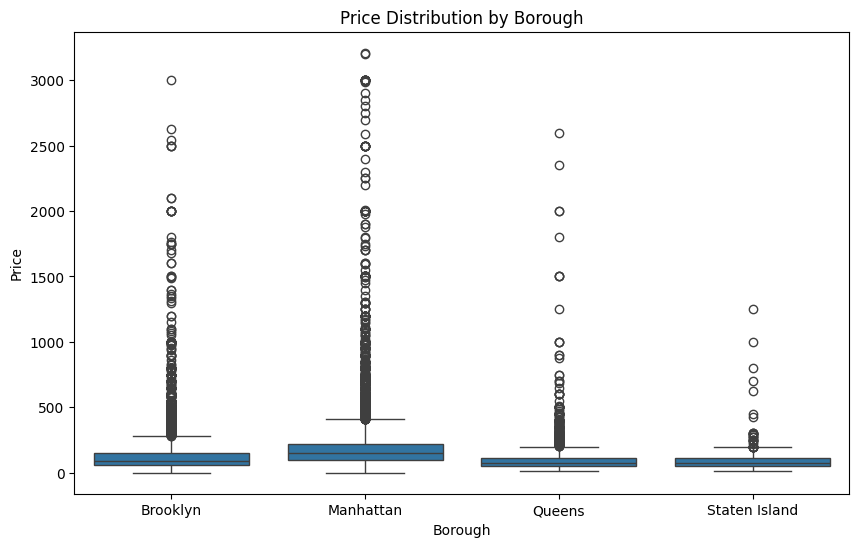

In [84]:
# Reconstruct neighbourhood_group from the one-hot encoded columns for visualization
group_cols = [col for col in df.columns if col.startswith('neighbourhood_group_')]
df['neighbourhood_group_label'] = df[group_cols].idxmax(axis=1).str.replace('neighbourhood_group_', '', regex=False)

# Visualize price by borough
plt.figure(figsize=(10, 6))
sns.boxplot(x='neighbourhood_group_label', y='price', data=df)
plt.title('Price Distribution by Borough')
plt.xlabel('Borough')
plt.ylabel('Price')
plt.show()

### Pairplot: relationships across multiple variables at once

A pairplot shows scatterplots for every pair of numeric variables simultaneously, along with each variable's own distribution on the diagonal.

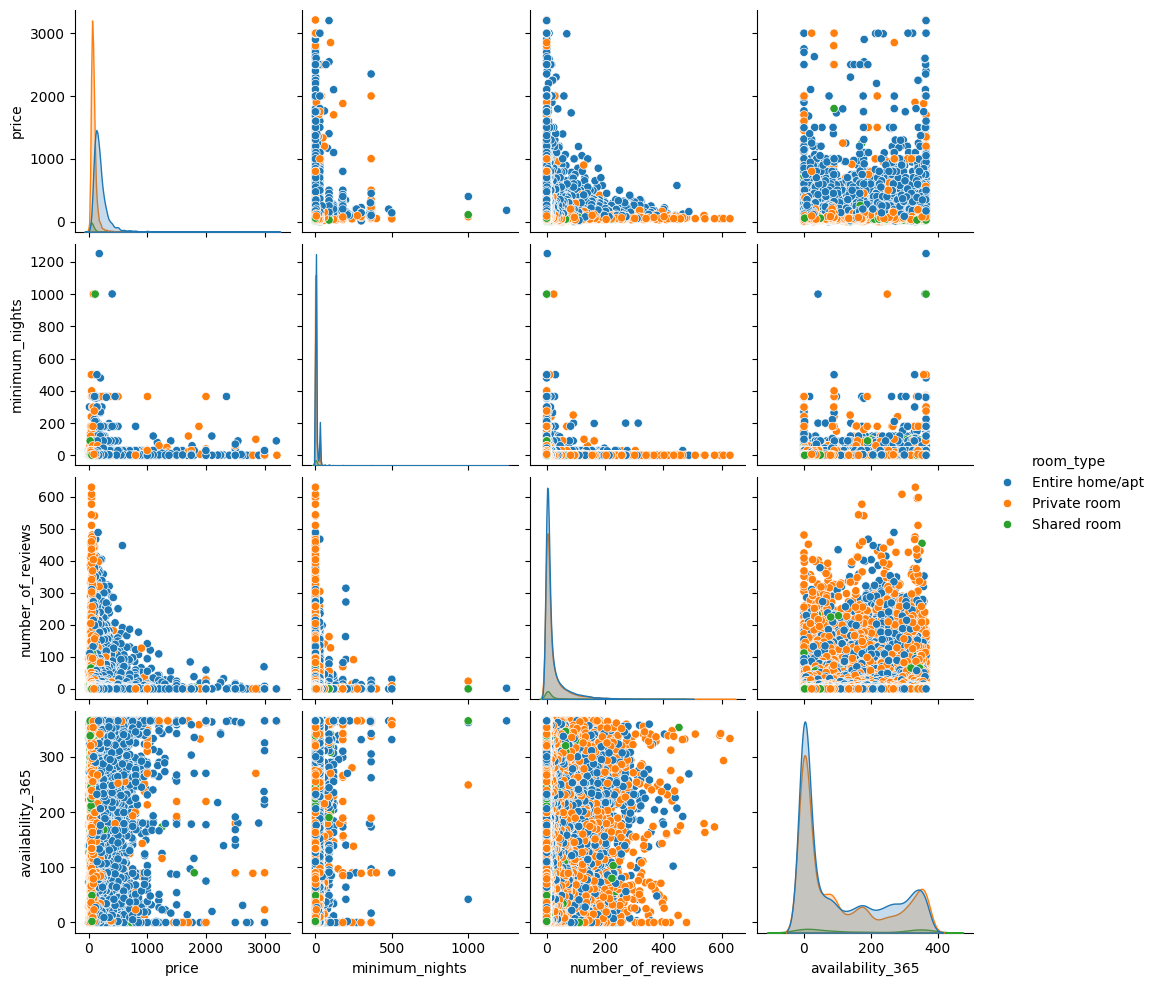

In [86]:
# Pairplot of key numeric variables, colored by room type
pairplot_cols = ['price', 'minimum_nights', 'number_of_reviews', 'availability_365', 'room_type']

sns.pairplot(df[pairplot_cols], hue='room_type', height=2.5, kind='scatter', diag_kind='kde')
plt.show()

### Mini Exercise

Using what we've learned, explore the following questions with an appropriate visualization (scatterplot, boxplot, or countplot):

1. **Availability vs. price category**: Do "expensive" listings tend to be available more or less often throughout the year compared to "Budget" listings?
   
2. **Number of reviews vs. price**: Do cheaper listings tend to get more reviews? Try a scatterplot of `price` vs. `number_of_reviews`.

For each, write 1–2 sentences on what pattern (if any) you observe.

In [88]:
# YOUR CODE HERE (Question 1)

In [89]:
# YOUR CODE HERE (Question 2)